### Тема: Дробовий факторний експеримент
**Датасет**: [Red Wine Quality (UCI / Kaggle)](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

#### **Завантаження та аналіз даних**

Задача: змоделювати якість вина (quality) як функцію від 4-х фізико-хімічних факторів.

In [1]:
import kagglehub

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
print("Path to dataset files:", path)

100%|██████████| 25.6k/25.6k [00:00<00:00, 25.8MB/s]

Extracting files...
Path to dataset files: /Users/mariia.m/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2


In [ ]:
import os

csv_path = os.path.join(path, 'winequality-red.csv')
df = pd.read_csv(csv_path, sep=',')

In [6]:
print(f'Розмір датасету: {df.shape[0]} рядків × {df.shape[1]} стовпців')
print(f'NULL values: {df.isnull().sum().sum()}')
df.head()

Розмір датасету: 1599 рядків × 12 стовпців
NULL values: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
# Описова статистика
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


Кореляційний аналіз факторів з цільовою змінною (quality)

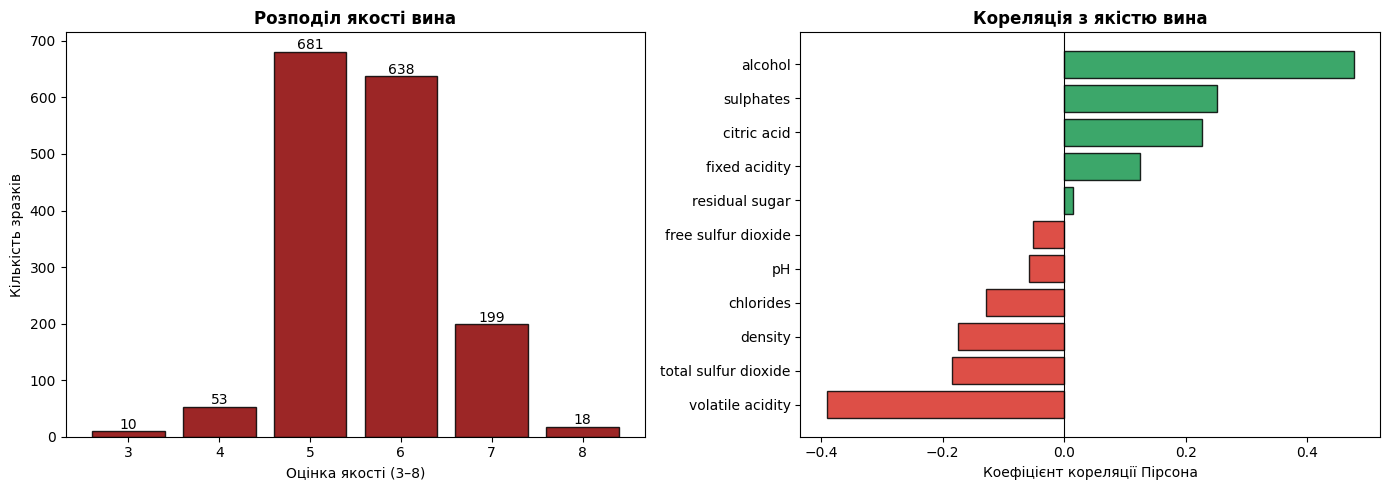

Кореляції:
volatile acidity       -0.390558
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
pH                     -0.057731
free sulfur dioxide    -0.050656
residual sugar          0.013732
fixed acidity           0.124052
citric acid             0.226373
sulphates               0.251397
alcohol                 0.476166


In [23]:
TARGET = 'quality'
corr = df.corr()[TARGET].drop(TARGET).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Розподіл якості
counts = df[TARGET].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color='#8B0000', edgecolor='black', alpha=0.85)
axes[0].set_title('Розподіл якості вина', fontweight='bold')
axes[0].set_xlabel('Оцінка якості (3–8)')
axes[0].set_ylabel('Кількість зразків')
for x, y in zip(counts.index, counts.values):
    axes[0].text(x, y + 4, str(y), ha='center', fontsize=10)

# Кореляції
colors = ['#1a9850' if v > 0 else '#d73027' for v in corr.values]
axes[1].barh(corr.index, corr.values, color=colors, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Кореляція з якістю вина', fontweight='bold')
axes[1].set_xlabel('Коефіцієнт кореляції Пірсона')

plt.tight_layout()
plt.show()

print('Кореляції:')
print(corr.to_string())

#### **Вибір факторів для ДФЕ**

Обираємо 4 фактори (ДФЕ 2^{4-1} = 8 дослідів) з найвищою абсолютною кореляцією:
- X₁ — alcohol (алкоголь)
- X₂ — volatile acidity (летка кислотність)
- X₃ — sulphates (сульфати)
- X₄ — citric acid (лимонна кислота)

In [24]:
FACTORS = {
    'X1': 'alcohol',
    'X2': 'volatile acidity',
    'X3': 'sulphates',
    'X4': 'citric acid',
}

Обчислення областей визначення факторів

In [27]:
params = {}

print("Таблиця 1 — Області визначення факторів та вихідної змінної\n")

factors = {}
for label, col in FACTORS.items():
    xmin, xmax = df[col].min(), df[col].max()
    x0 = (xmax + xmin) / 2
    dx = (xmax - xmin) / 2
    
    params[label] = {'x0': x0, 'dx': dx}
    factors[label] = {'col': col, 'min': xmin, 'max': xmax, 'x0': x0, 'dx': dx}
    
    print(f"{label} ({col}): [{xmin:.2f}, {xmax:.2f}] | Нул. рівень X0: {x0:.2f} | Інт. вар. ΔX: {dx:.2f}")

print(f"\ny ({TARGET}): [{df[TARGET].min()}, {df[TARGET].max()}]")

Таблиця 1 — Області визначення факторів та вихідної змінної

X1 (alcohol): [8.40, 14.90] | Нул. рівень X0: 11.65 | Інт. вар. ΔX: 3.25
X2 (volatile acidity): [0.12, 1.58] | Нул. рівень X0: 0.85 | Інт. вар. ΔX: 0.73
X3 (sulphates): [0.33, 2.00] | Нул. рівень X0: 1.17 | Інт. вар. ΔX: 0.83
X4 (citric acid): [0.00, 1.00] | Нул. рівень X0: 0.50 | Інт. вар. ΔX: 0.50

y (quality): [3, 8]


#### **TASK 1: Кодування вихідної інформації**

Виконуємо кодування кожного фактора за формулою: x_i = (X_i - X_i0) / ΔX_i

In [ ]:
df_coded = df.copy()
for label, factor in factors.items():
    df_coded[label] = (df[factor['col']] - factor['x0']) / factor['dx']
    
print('Таблиця кодування (перші 8 рядків)\n')

show = pd.DataFrame()
for label, factor in factors.items():
    show[f'{label} ({factor["col"][:8]}..)'] = df[factor['col']].values[:8].round(3)
    show[f'{label}_код'] = df_coded[label].values[:8].round(3)
print(show.to_string(index=False))

Таблиця кодування

 X1 (alcohol..)  X1_код  X2 (volatile..)  X2_код  X3 (sulphate..)  X3_код  X4 (citric a..)  X4_код
            9.4  -0.692             0.70  -0.205             0.56  -0.725             0.00   -1.00
            9.8  -0.569             0.88   0.041             0.68  -0.581             0.00   -1.00
            9.8  -0.569             0.76  -0.123             0.65  -0.617             0.04   -0.92
            9.8  -0.569             0.28  -0.781             0.58  -0.701             0.56    0.12
            9.4  -0.692             0.70  -0.205             0.56  -0.725             0.00   -1.00
            9.4  -0.692             0.66  -0.260             0.56  -0.725             0.00   -1.00
            9.4  -0.692             0.60  -0.342             0.46  -0.844             0.06   -0.88
           10.0  -0.508             0.65  -0.274             0.47  -0.832             0.00   -1.00


Перевірка діапазону кодованих значень (має бути [- 1, + 1])

In [30]:
for label in factors:
    mn = df_coded[label].min(); mx = df_coded[label].max()
    print(f'  {label}: [{mn:.4f}, {mx:.4f}]')

  X1: [-1.0000, 1.0000]
  X2: [-1.0000, 1.0000]
  X3: [-1.0000, 1.0000]
  X4: [-1.0000, 1.0000]


#### **TASK 2: Вибір генерувальних співвідношень**

Будуємо повний ФЕ 2^3 для перших 3-х факторів, четвертий визначаємо через генерувальне співвідношення:
`x4 = x1 * x2 * x3`

In [32]:
k_base = 3  # к-ть базових факторів
k_total = 4  # загальна к-ть факторів
p = 1  # к-ть генерувальних співвідношень
N = 2**k_base  # к-ть дослідів

Побудова матриці планування ДФЕ 2^(4-1)

In [33]:
from itertools import product

base_levels = list(product([-1, 1], repeat=k_base))
plan = pd.DataFrame(base_levels, columns=['x1', 'x2', 'x3'])

plan['x4'] = plan['x1'] * plan['x2'] * plan['x3']

plan.insert(0, 'x0', 1)
plan['x1x2'] = plan['x1'] * plan['x2']
plan['x1x3'] = plan['x1'] * plan['x3']
plan['x2x3'] = plan['x2'] * plan['x3']

plan.index = range(1, N+1)
plan.index.name = 'Дослід'

In [34]:
print('Таблиця 2 — Матриця планування ДФЕ 2^(4-1)')
print('(x4 = x1·x2·x3 — генерувальне співвідношення)')
print()
print(plan.to_string())

Таблиця 2 — Матриця планування ДФЕ 2^(4-1)
(x4 = x1·x2·x3 — генерувальне співвідношення)

        x0  x1  x2  x3  x4  x1x2  x1x3  x2x3
Дослід                                      
1        1  -1  -1  -1  -1     1     1     1
2        1  -1  -1   1   1     1    -1    -1
3        1  -1   1  -1   1    -1     1    -1
4        1  -1   1   1  -1    -1    -1     1
5        1   1  -1  -1   1    -1    -1     1
6        1   1  -1   1  -1    -1     1    -1
7        1   1   1  -1  -1     1    -1    -1
8        1   1   1   1   1     1     1     1


Перевірка матриці на ортогональність

In [35]:
X_cols = ['x0','x1','x2','x3','x4','x1x2','x1x3','x2x3']
Xm = plan[X_cols].values.astype(float)
XtX = Xm.T @ Xm
is_orth = np.allclose(XtX - np.diag(np.diag(XtX)), 0)
print(f'\nМатриця ортогональна: {is_orth} (X^T·X = {N}·I)')


Матриця ортогональна: True (X^T·X = 8·I)


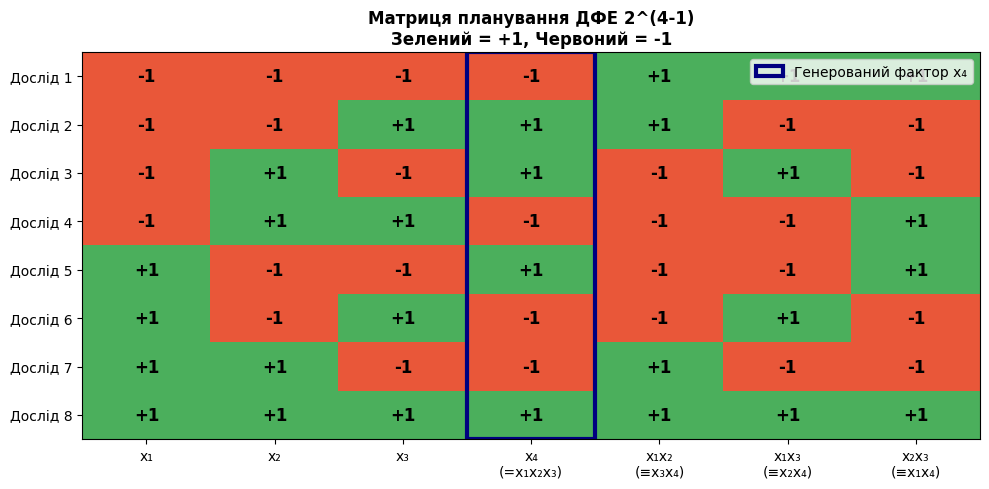

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
data_vis = plan[['x1','x2','x3','x4','x1x2','x1x3','x2x3']].values
im = ax.imshow(data_vis, cmap='RdYlGn', vmin=-1.5, vmax=1.5, aspect='auto')
ax.set_xticks(range(7))
ax.set_xticklabels(['x₁','x₂','x₃','x₄\n(=x₁x₂x₃)','x₁x₂\n(≡x₃x₄)','x₁x₃\n(≡x₂x₄)','x₂x₃\n(≡x₁x₄)'], fontsize=10)
ax.set_yticks(range(N))
ax.set_yticklabels([f'Дослід {i+1}' for i in range(N)])
ax.set_title('Матриця планування ДФЕ 2^(4-1)\nЗелений = +1, Червоний = -1', fontweight='bold')

for i in range(N):
    for j in range(7):
        val = int(data_vis[i, j])
        ax.text(j, i, f'{val:+d}', ha='center', va='center', fontweight='bold', fontsize=12)

# Виділяємо x4 як генерований
ax.add_patch(plt.Rectangle((2.5, -0.5), 1, N, fill=False,
             edgecolor='navy', linewidth=3, label='Генерований фактор x₄'))
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### **Формування вихідної таблиці**

Для кожного з 8 дослідів відбираємо відповідні спостереження з датасету та обчислюємо:
- $Y_{U1}, Y_{U2}, \ldots$ — повторні спостереження якості
- $\bar{Y}$ — середнє (результат «досліду»)
- $S_i^2$ — вибіркова дисперсія (для перевірки Кохрена)

Медіани факторів для розбиття

In [37]:
factor_cols = [info['col'] for info in factors.values()]
medians = {col: df[col].median() for col in factor_cols}

print('Медіани факторів (пороги рівнів):')
for label, info in factors.items():
    col = info['col']
    m = medians[col]
    print(f'  {label} ({col:20}): медіана = {m:.4f}')
    print(f'    рівень −1: X ≤ {m:.4f}  |  рівень +1: X > {m:.4f}')

Медіани факторів (пороги рівнів):
  X1 (alcohol             ): медіана = 10.2000
    рівень −1: X ≤ 10.2000  |  рівень +1: X > 10.2000
  X2 (volatile acidity    ): медіана = 0.5200
    рівень −1: X ≤ 0.5200  |  рівень +1: X > 0.5200
  X3 (sulphates           ): медіана = 0.6200
    рівень −1: X ≤ 0.6200  |  рівень +1: X > 0.6200
  X4 (citric acid         ): медіана = 0.2600
    рівень −1: X ≤ 0.2600  |  рівень +1: X > 0.2600


Обчислення y_mean та дисперсії для кожного досліду ДФЕ

In [38]:
base_factor_cols = [factors['X1']['col'],
                    factors['X2']['col'],
                    factors['X3']['col'],
                    factors['X4']['col']]
M_REPEATS = 5

In [39]:
results = []
for i, (lvl1, lvl2, lvl3) in enumerate(base_levels):
    lvl4 = lvl1 * lvl2 * lvl3
    lvls = [lvl1, lvl2, lvl3, lvl4]

    masks = []
    for lvl, col in zip(lvls, base_factor_cols):
        med = medians[col]
        masks.append(df[col] <= med if lvl == -1 else df[col] > med)
    mask = masks[0] & masks[1] & masks[2] & masks[3]

    subset = df.loc[mask, TARGET]
    n_obs  = len(subset)
    y_mean = subset.mean()
    y_var  = subset.var(ddof=1) if n_obs > 1 else 0.0

    sample_vals = subset.values[:M_REPEATS] if n_obs >= M_REPEATS else subset.values

    results.append({
        'x1': lvl1, 'x2': lvl2, 'x3': lvl3, 'x4': lvl4,
        'n_obs': n_obs,
        'y_mean': y_mean,
        'y_var': y_var,
        'repeats': sample_vals,
    })

results_df = pd.DataFrame(results)
results_df.index = range(1, N+1)
results_df.index.name = 'Дослід'

In [42]:
table2 = results_df[['x1','x2','x3','x4']].copy()

for m in range(M_REPEATS):
    table2[f'Y_U{m+1}'] = [r['repeats'][m] if m < len(r['repeats']) else np.nan for r in results]

table2['Ȳ'] = results_df['y_mean'].round(4)
table2['S²'] = results_df['y_var'].round(4)
table2['n'] = results_df['n_obs']

print('Таблиця 2 — Вихідні дані ДФЕ 2^(4-1)')
print()
print(table2.to_string())

Таблиця 2 — Вихідні дані ДФЕ 2^(4-1)

        x1  x2  x3  x4  Y_U1  Y_U2  Y_U3  Y_U4  Y_U5       Ȳ      S²    n
Дослід                                                                   
1       -1  -1  -1  -1     5     5     5     5     5  5.2817  0.3195   71
2       -1  -1   1   1     6     5     7     5     5  5.6992  0.6058  133
3       -1   1  -1   1     4     6     6     5     5  5.1385  0.3399   65
4       -1   1   1  -1     5     5     5     5     5  5.2793  0.3486  111
5        1  -1  -1   1     6     6     6     6     5  5.9623  0.5128  106
6        1  -1   1  -1     6     5     5     6     6  6.1556  0.4980   45
7        1   1  -1  -1     6     6     5     5     5  5.4752  0.6940  141
8        1   1   1   1     6     5     7     7     7  6.1471  0.6747   34


#### **TASK 3: Розрахунок коефіцієнтів рівнянь**

Матриця ортогональна -> визначаємо коефіцієнти планування за формулою: b = (1/N) * X^T * y

In [44]:
X_plan = plan[X_cols].values.astype(float)
y_bar  = results_df['y_mean'].values
b = (X_plan.T @ y_bar) / N

In [45]:
coef_names  = ['b0',  'b1',  'b2',  'b3',  'b4',  'b12',   'b13',   'b23']
coef_alias  = ['',    '',    '',    '',    'b123','b34',   'b24',   'b14']
coef_labels = [
    'Вільний член',
    'Алкоголь (X₁)',
    'Летка кислотність (X₂)',
    'Сульфати (X₃)',
    'Лимонна кислота (X₄)  [≡ b₁₂₃]',
    'Взаємодія x₁x₂  [≡ b₃₄]',
    'Взаємодія x₁x₃  [≡ b₂₄]',
    'Взаємодія x₂x₃  [≡ b₁₄]',
]

coef_df = pd.DataFrame({
    'Коефіцієнт': coef_names,
    'Змішаний з': coef_alias,
    'Значення': b,
    'Опис': coef_labels
}).set_index('Коефіцієнт')

print('Таблиця 3 — Коефіцієнти рівняння регресії ДФЕ')
print()
print(coef_df.to_string())

Таблиця 3 — Коефіцієнти рівняння регресії ДФЕ

           Змішаний з  Значення                            Опис
Коефіцієнт                                                     
b0                     5.642342                    Вільний член
b1                     0.292672                   Алкоголь (X₁)
b2                    -0.132348          Летка кислотність (X₂)
b3                     0.177944                   Сульфати (X₃)
b4               b123  0.094416  Лимонна кислота (X₄)  [≡ b₁₂₃]
b12               b34  0.008452         Взаємодія x₁x₂  [≡ b₃₄]
b13               b24  0.038350         Взаємодія x₁x₃  [≡ b₂₄]
b23               b14  0.025231         Взаємодія x₂x₃  [≡ b₁₄]


Формулюємо рівняння

In [48]:
var_map = {'b0':'', 'b1':'x₁', 'b2':'x₂', 'b3':'x₃', 'b4':'x₄', 'b12':'x₁x₂', 'b13':'x₁x₃', 'b23':'x₂x₃'}

terms = []
for name, bj in zip(coef_names, b):
    vi = var_map[name]
    if vi == '':
        terms.append(f'{bj:.4f}')
    elif bj >= 0:
        terms.append(f'+ {bj:.4f}·{vi}')
    else:
        terms.append(f'- {abs(bj):.4f}·{vi}')
        
print('Рівняння регресії:\n')
print('ŷ = ' + ' '.join(terms))

Рівняння регресії:

ŷ = 5.6423 + 0.2927·x₁ - 0.1323·x₂ + 0.1779·x₃ + 0.0944·x₄ + 0.0085·x₁x₂ + 0.0383·x₁x₃ + 0.0252·x₂x₃


#### **TASK 4: Перевірка однорідності дисперсій**

Критерій Корхена

#### **TASK 5: Перевірка значущості коефіцієнта рівняння регресії**

t-критерій Стьюдента

#### **TASK 6: Перевірка адекватності математичної моделі**

Критерій Фішера